# Paper A · Experiment 4 — Sensitivity-weighted loss

**The idea.** The baseline trains with `L = Σ MSEᵢ` — every landmark weighted equally. E1
showed they are not equal: a pixel of error on the lateral plateau costs ~10× the angle
error of the same pixel on the hinge. E4 reweights the loss by influence,
$w_i \propto \lVert J_i\rVert$, so the network spends precision where it converts into
angle accuracy, and asks whether the **clinical** error improves **at matched pixel error**.

**This is a redistribution test, not an accuracy test.** E1 found the in-domain median angle
error (0.35°) already sits at inter-observer agreement (0.30–0.33°) — there is no headroom in
the mean. So E4 holds the pixel-error budget fixed and moves it from landmarks that don't
matter (hinge) to landmarks that do (plateau, femoral head). If MRE is unchanged but the
angle error falls, that is the redistribution, isolated.

**Three realities this notebook is built around** (all from E1/E3):

1. **The mean is saturated** — E4 can only help the *tail*, and an in-domain null is a valid,
   pre-committed outcome.
2. **The tail is unmeasurable as a rate** — 1 of 107 hemispheres is out of tolerance. The
   headline metric is therefore the **paired per-landmark change in localisation error** (107
   paired samples per landmark, well powered), plus paired angle-error *quantiles* with a
   bootstrap CI — **not** the out-of-tolerance rate.
3. **A decode floor caps pure reweighting** — argmax on a half-resolution heatmap contributes
   ~9 px of quantisation the loss cannot remove. So the optional differentiable-measurement
   arm (soft-argmax + `|g(p̂) − g(p)|`) is included: it attacks the clinical quantity directly
   and bypasses the floor.

**The falsifiable prediction.** E1: sensitivity spans 10× but localisation error is *flat*
(1.36×). A sensitivity-weighted loss should make localisation error **non-flat** — tighten
the plateau and femoral head, and *let the hinge get worse*. §7 tests exactly this.

## 0 · Configuration

Mirrors cell 0 of `hto_unet_baseline.ipynb`; only the loss changes between arms. Training is
expensive — set `DEV_MODE = True` for a 2-fold, short-epoch smoke test before the full run.

In [1]:
import json
import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader

from hto.data import GlobalRadiographKeypointDataset
from hto.geometry import evaluate_side_geometry, map_global_to_orig
from hto.metrics import calculate_mse, calculate_pck, extract_coordinates, masked_heatmap_loss
from hto.model import UNetKeypointHalfHeatmap
from hto.sensitivity import (
    LANDMARK_LABELS, SIDE_KEYS, TOLERANCE_DEG,
    cohort_jacobians, miniaci_angle_signed, precision_budget, wrap_deg,
)

# ---- baseline constants (do not drift from the baseline notebook) ----------
DATA_DIR       = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

SEED, TARGET_SIZE, HEATMAP_SCALE, SIGMA = 42, 768, 0.5, 6.0
BATCH_SIZE     = 4
LEARNING_RATE  = 1e-4 * (HEATMAP_SCALE / 0.25)      # 2e-4, as in the baseline
UNET_BASE_CH, UNET_BILINEAR = 64, False
PCK_THRESHOLDS = [0.005, 0.01, 0.02, 0.05]

# ---- E4 knobs --------------------------------------------------------------
DEV_MODE       = False          # True -> quick smoke test (2 folds, few epochs)
EPOCHS         = 60 if DEV_MODE else 750
N_SPLITS       = 2 if DEV_MODE else 5
WEIGHT_POWER   = 1             # w_i ∝ ||J_i||^POWER ; 1 or 2
WEIGHT_MODE    = "cohort"      # "cohort" (fixed median ||J||) or "percase" (per-image J)
USE_MEASUREMENT = False        # optional: add lambda*|g(p_hat)-g(p)| via soft-argmax
MEASUREMENT_LAMBDA = 0.1
ARMS = ["equal", "weighted"]   # add "weighted_meas" to also run the measurement arm
N_BOOTSTRAP    = 5000

CKPT_DIR = Path("kfolds_models_e4"); CKPT_DIR.mkdir(exist_ok=True)
OUT_DIR  = Path("results/E4");       OUT_DIR.mkdir(parents=True, exist_ok=True)

SIDE_BASES = [(0, "left"), (6, "right")]           # channel base -> hemisphere
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

seed_everything()
print(f"torch {torch.__version__} | device {device} | DEV_MODE={DEV_MODE} "
      f"| {N_SPLITS} folds x {EPOCHS} epochs x {len(ARMS)} arms")

torch 2.5.1+cu121 | device cuda | DEV_MODE=False | 5 folds x 750 epochs x 2 arms


## 1 · Channel weights from $\lVert J\rVert$

The weight of each heatmap channel is the landmark's sensitivity, $\lVert J_i\rVert^{p}$.
Weights are **normalised to mean 1** across the 12 channels, so the overall loss scale — and
therefore the effective learning rate — matches the baseline. That is what makes "equal vs
weighted at matched MRE" a fair comparison rather than a learning-rate change in disguise.

`cohort` mode uses the E1 median $\lVert J_i\rVert$ (fixed, stable, reproducible). `percase`
mode recomputes weights from each image's own ground-truth landmarks; the *ratios* across
landmarks are scale-invariant, so it is well defined per image.

In [2]:
# Recompute J on the ground-truth cohort (identical to E1). Needs the annotations.
_gt_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="all", target_size=TARGET_SIZE,
                                         heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
_gt_points = []
for s in _gt_ds.samples:
    kp = s["keypoints"]
    coords = np.array([[kp[i * 3], kp[i * 3 + 1]] for i in range(12)], dtype=float)
    vis = np.array([kp[i * 3 + 2] for i in range(12)])
    for base, _sd in SIDE_BASES:
        if all(vis[base + o] > 0 for o in range(6)):
            _gt_points.append({name: coords[base + o] for o, name in enumerate(SIDE_KEYS)})

J_gt, _, _ = cohort_jacobians(_gt_points)
J_norm_median = np.median(np.linalg.norm(J_gt, axis=2), axis=0)     # (6,) per SIDE_KEYS
print("median ||J_i|| (deg/px):")
for name, v in zip(SIDE_KEYS, J_norm_median):
    print(f"  {LANDMARK_LABELS[name]:24s} {v:.5f}")


def channel_weights(power=WEIGHT_POWER, jnorm=J_norm_median):
    # (12,) tensor, mean 1: [left 6 ; right 6], both hemispheres weighted the same.
    w6 = np.asarray(jnorm, dtype=float) ** power
    w12 = np.concatenate([w6, w6])
    w12 = w12 * (12.0 / w12.sum())
    return torch.tensor(w12, dtype=torch.float32)


W_EQUAL    = torch.ones(12, dtype=torch.float32)
W_WEIGHTED = channel_weights()
print(f"\nweighted channel weights (mean {float(W_WEIGHTED.mean()):.3f}): "
      f"{np.round(W_WEIGHTED.numpy(), 3)}")
print(f"plateau/hinge weight ratio: {float(W_WEIGHTED[3] / W_WEIGHTED[2]):.1f}x")

median ||J_i|| (deg/px):
  Femoral head centre      0.01943
  Medial tibial plateau    0.01616
  Osteotomy hinge          0.00254
  Lateral tibial plateau   0.02693
  Medial malleolus         0.01142
  Lateral malleolus        0.01142

weighted channel weights (mean 1.000): [1.326 1.103 0.173 1.838 0.78  0.78  1.326 1.103 0.173 1.838 0.78  0.78 ]
plateau/hinge weight ratio: 10.6x


## 2 · Losses

`weighted_heatmap_loss` is the baseline's masked MSE with a per-channel weight vector; at
`w = 1` it is **identical** to `hto.metrics.masked_heatmap_loss`, so the equal arm reproduces
the baseline exactly and the two arms differ only in the weights.

The optional measurement term decodes coordinates with a differentiable **soft-argmax** and
penalises the correction-angle error directly via `hto.sensitivity.miniaci_angle_signed`. The
angle is invariant to the letterbox scale, so it is computed in canvas coordinates.

In [3]:
def weighted_heatmap_loss(pred_hms, target_hms, visibility, channel_w):
    # Baseline masked MSE, per-channel weighted. channel_w: (K,) on the model's device.
    mask = visibility.unsqueeze(-1).unsqueeze(-1)                  # (B, K, 1, 1)
    w = channel_w.view(1, -1, 1, 1)
    masked_diff = (pred_hms - target_hms) ** 2 * mask * w
    H, W = pred_hms.shape[-2], pred_hms.shape[-1]
    return masked_diff.sum() / (mask.sum().clamp(min=1) * H * W)


def soft_argmax(heatmaps):
    # Differentiable coordinate decode. heatmaps: (B, K, h, w) -> coords (B, K, 2) in grid px.
    B, K, h, w = heatmaps.shape
    flat = heatmaps.reshape(B, K, -1)
    prob = torch.softmax(flat, dim=-1).reshape(B, K, h, w)
    xs = torch.arange(w, device=heatmaps.device, dtype=heatmaps.dtype)
    ys = torch.arange(h, device=heatmaps.device, dtype=heatmaps.dtype)
    ex = (prob.sum(-2) * xs).sum(-1)                               # (B, K)
    ey = (prob.sum(-1) * ys).sum(-1)
    return torch.stack([ex, ey], dim=-1)                          # (B, K, 2)


def angle_consistency_loss(pred_hms, gt_keypoints, visibility):
    # lambda-free mean |wrap(pred_angle - gt_angle)| over complete hemispheres in the batch.
    # gt_keypoints: (B, 12, 2) canvas coords; angle is scale-invariant so canvas is fine.
    coords = soft_argmax(pred_hms) / HEATMAP_SCALE                 # -> canvas px, (B, 12, 2)
    terms = []
    for b in range(pred_hms.shape[0]):
        for base, _sd in SIDE_BASES:
            if not bool((visibility[b, base:base + 6] > 0).all()):
                continue
            P_pred = coords[b, base:base + 6]                     # (6, 2), keeps grad
            P_gt = gt_keypoints[b, base:base + 6].to(pred_hms.device)
            a_pred = miniaci_angle_signed(P_pred)
            a_gt = miniaci_angle_signed(P_gt.double()).detach()
            d = a_pred - a_gt
            terms.append(torch.abs(torch.atan2(torch.sin(d * math.pi / 180),
                                               torch.cos(d * math.pi / 180)) * 180 / math.pi))
    if not terms:
        return torch.zeros((), device=pred_hms.device)
    return torch.stack(terms).mean()


def make_loss_fn(arm):
    # Returns loss_fn(pred_hms, batch, dev) -> scalar for the given arm.
    w = {"equal": W_EQUAL, "weighted": W_WEIGHTED, "weighted_meas": W_WEIGHTED}[arm]
    use_meas = USE_MEASUREMENT or arm == "weighted_meas"

    def loss_fn(pred_hms, batch, dev):
        base = weighted_heatmap_loss(pred_hms, batch["heatmap"].to(dev),
                                     batch["visibility"].to(dev), w.to(dev))
        if use_meas:
            base = base + MEASUREMENT_LAMBDA * angle_consistency_loss(
                pred_hms, batch["keypoint"], batch["visibility"].to(dev))
        return base

    return loss_fn


# sanity: at w=1 the weighted loss equals the baseline masked loss
_p = torch.rand(2, 12, 8, 8); _t = torch.rand(2, 12, 8, 8); _v = torch.ones(2, 12)
assert torch.allclose(weighted_heatmap_loss(_p, _t, _v, W_EQUAL),
                      masked_heatmap_loss(_p, _t, _v), atol=1e-7), "equal arm != baseline loss"
print("equal-arm loss reproduces hto.metrics.masked_heatmap_loss  OK")

equal-arm loss reproduces hto.metrics.masked_heatmap_loss  OK


## 3 · Augmentation and training loop

`apply_augmentation` and `train_routine` are copied faithfully from
`hto_unet_baseline.ipynb` — the *only* deviation is that the loss is passed in as `loss_fn`,
so both arms run through byte-for-byte the same loop. Keep in sync with the baseline (or, in
future, both should import a shared `hto.train`).

A `tqdm` bar runs over epochs; its postfix updates every epoch with **train loss, val loss,
val MSE, and PCK@0.005 / @0.01 / @0.05** (percent). The full per-epoch history is also
returned and written to `kfolds_models_e4/{arm}_fold{k}_history.csv` for later curves.

In [4]:
import cv2
import torchvision.transforms.functional as TF
from PIL import Image

try:
    from tqdm.auto import tqdm                            # nice bar in Jupyter or console
except ImportError:                                       # graceful fallback (pip install tqdm)
    class tqdm:
        def __init__(self, iterable=None, total=None, desc="", **kw):
            self.iterable = iterable if iterable is not None else range(total or 0)
            self.desc = desc
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix(self, d=None, **kw):
            print(f"  {self.desc} | " + "  ".join(f"{k}={v}" for k, v in {**(d or {}), **kw}.items()))


def apply_augmentation(pil_img, final_kps):
    # Verbatim from hto_unet_baseline.ipynb.
    img = pil_img
    kps = [list(kp) for kp in final_kps]
    W, H = img.size
    if random.random() < 0.6:
        img = TF.adjust_brightness(img, 1.0 + random.uniform(-0.25, 0.25))
    if random.random() < 0.6:
        img = TF.adjust_contrast(img, 1.0 + random.uniform(-0.25, 0.25))
    if random.random() < 0.4:
        arr = np.array(img, dtype=np.float32)
        arr = np.clip(arr + np.random.normal(0, random.uniform(3, 12), arr.shape), 0, 255)
        img = Image.fromarray(arr.astype(np.uint8))
    if random.random() < 0.5:
        gamma = random.uniform(0.7, 1.4)
        arr = np.array(img, dtype=np.float32) / 255.0
        img = Image.fromarray((np.power(arr, gamma) * 255).astype(np.uint8))
    if random.random() < 0.4:
        arr = np.array(img)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = Image.fromarray(np.stack([clahe.apply(arr[:, :, 0])] * 3, axis=2))
    if random.random() < 0.3:
        img = TF.adjust_sharpness(img, random.uniform(0.5, 2.0))
    if random.random() < 0.5:
        angle = random.uniform(-10, 10)
        img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
        cx, cy = W / 2.0, H / 2.0
        rad = math.radians(-angle); ca, sa = math.cos(rad), math.sin(rad)
        for kp in kps:
            if kp[0] < 0: continue
            dx, dy = kp[0] - cx, kp[1] - cy
            kp[0], kp[1] = ca * dx - sa * dy + cx, sa * dx + ca * dy + cy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H): kp[0], kp[1] = -1.0, -1.0
    if random.random() < 0.3:
        sy = random.randint(-15, 15)
        img = TF.affine(img, angle=0, translate=(0, sy), scale=1.0, shear=0)
        for kp in kps:
            if kp[0] < 0: continue
            kp[1] += sy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H): kp[0], kp[1] = -1.0, -1.0
    if random.random() < 0.3:
        sf = random.uniform(0.90, 1.10)
        nw, nh = int(W * sf), int(H * sf)
        img = TF.resize(img, [nh, nw])
        if sf < 1.0:
            pl, pt = (W - nw) // 2, (H - nh) // 2
            pad = Image.new("RGB", (W, H), (0, 0, 0)); pad.paste(img, (pl, pt))
            img, ox, oy = pad, pl, pt
        else:
            cl, ct = (nw - W) // 2, (nh - H) // 2
            img = TF.crop(img, ct, cl, H, W); ox, oy = -cl, -ct
        for kp in kps:
            if kp[0] < 0: continue
            kp[0], kp[1] = kp[0] * sf + ox, kp[1] * sf + oy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H): kp[0], kp[1] = -1.0, -1.0
    return img, kps


PCK_DISPLAY = (0.005, 0.01, 0.05)                          # thresholds shown live


def train_routine(model, t_loader, v_loader, opt, sched, epochs, dev, loss_fn, ckpt, desc=""):
    # Mirrors baseline train_global_routine; loss is loss_fn(pred_hms, batch, dev).
    # A tqdm bar over epochs shows train/val loss, val MSE and PCK live in its postfix.
    best_mse = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_mse": [],
               **{f"pck@{t}": [] for t in PCK_DISPLAY}}
    bar = tqdm(range(epochs), desc=desc, leave=True)
    for e in bar:
        model.train()
        t_sum = 0.0
        for batch in t_loader:
            opt.zero_grad()
            pred = model(batch["image"].to(dev))
            loss = loss_fn(pred, batch, dev)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            t_sum += loss.item()
        sched.step()
        t_loss = t_sum / max(len(t_loader), 1)

        model.eval()
        v_sum, preds, gts = 0.0, [], []
        with torch.no_grad():
            for batch in v_loader:
                pred = model(batch["image"].to(dev))
                v_sum += loss_fn(pred, batch, dev).item()          # same loss as training
                preds.append(extract_coordinates(pred.cpu(), scale_factor=1.0 / HEATMAP_SCALE))
                gts.append(batch["keypoint"])
        v_loss = v_sum / max(len(v_loader), 1)
        preds_cat, gts_cat = torch.cat(preds), torch.cat(gts)
        mse_val = calculate_mse(preds_cat, gts_cat)
        pck = {t: calculate_pck(preds_cat, gts_cat, threshold=t, normalize_by=TARGET_SIZE)
               for t in PCK_DISPLAY}

        if mse_val < best_mse:
            best_mse = mse_val
            torch.save(model.state_dict(), ckpt)

        history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
        history["val_mse"].append(mse_val)
        for t in PCK_DISPLAY: history[f"pck@{t}"].append(pck[t])
        bar.set_postfix({
            "tr_loss": f"{t_loss:.4f}", "val_loss": f"{v_loss:.4f}", "val_mse": f"{mse_val:.1f}",
            "pck.005": f"{100 * pck[0.005]:.1f}", "pck.01": f"{100 * pck[0.01]:.1f}",
            "pck.05": f"{100 * pck[0.05]:.1f}",
        })
    return best_mse, history

print("augmentation + training loop ready")

augmentation + training loop ready


## 4 · Per-hemisphere evaluation

For a trained model, decode out-of-fold predictions and record, per complete hemisphere:
the six **per-landmark localisation errors** (original px) — the raw material for the
mechanism test — and the predicted vs ground-truth correction angle.

In [5]:
def evaluate_hemispheres(model, loader, dev):
    model.eval()
    out = []
    with torch.no_grad():
        for batch in loader:
            pred = extract_coordinates(model(batch["image"].to(dev)).cpu(),
                                       scale_factor=1.0 / HEATMAP_SCALE).numpy()
            gts = batch["keypoint"].numpy()
            sizes = batch["orig_size"].numpy()
            for b, path in enumerate(batch["img_path"]):
                for base, sd in SIDE_BASES:
                    if not all(gts[b][base + o][0] >= 0 for o in range(6)):
                        continue
                    pg, pp, errs = {}, {}, {}
                    for o, name in enumerate(SIDE_KEYS):
                        g = map_global_to_orig(gts[b][base + o], sizes[b], TARGET_SIZE)
                        p = map_global_to_orig(pred[b][base + o], sizes[b], TARGET_SIZE)
                        pg[name], pp[name] = g, p
                        errs[name] = float(np.linalg.norm(p - g))
                    a_gt = evaluate_side_geometry(pg)[0]
                    a_pred = evaluate_side_geometry(pp)[0]
                    rec = {"case_id": Path(path).stem, "side": sd,
                           "angle_gt": a_gt, "angle_pred": a_pred,
                           "angle_err": abs(a_pred - a_gt),
                           "mre": float(np.mean(list(errs.values())))}
                    rec.update({f"err_{k}": v for k, v in errs.items()})
                    out.append(rec)
    return out

print("evaluator ready")

evaluator ready


## 5 · Train the arms (5-fold, out-of-fold)

Every arm uses the **same folds, seed, budget and augmentation** — only `loss_fn` differs.
Out-of-fold predictions are pooled to `n = 107`, so the arms are paired case-by-case. This is
the long cell; each arm is `N_SPLITS × EPOCHS`.

In [6]:
def run_arm(arm):
    print(f"\n=== arm: {arm} ===")
    seed_everything()
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    loss_fn = make_loss_fn(arm)
    records = []
    for fold, (tr, va) in enumerate(kf.split(np.arange(len(_gt_ds))), 1):
        tr_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="train",
                    target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA,
                    seed=SEED, indices=tr, augment_fn=apply_augmentation)
        va_ds = GlobalRadiographKeypointDataset(COCO_JSON_PATH, split="val",
                    target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA,
                    seed=SEED, indices=va)
        tl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
        vl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False)
        model = UNetKeypointHalfHeatmap(num_keypoints=12, base_ch=UNET_BASE_CH,
                                        bilinear=UNET_BILINEAR).to(device)
        opt = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)
        ckpt = CKPT_DIR / f"{arm}_fold{fold}.pt"
        best, hist = train_routine(model, tl, vl, opt, sched, EPOCHS, device, loss_fn, ckpt,
                                   desc=f"{arm} fold{fold}/{N_SPLITS}")
        pd.DataFrame(hist).to_csv(CKPT_DIR / f"{arm}_fold{fold}_history.csv", index=False)
        model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
        fold_recs = evaluate_hemispheres(model, vl, device)
        for r in fold_recs:
            r["arm"], r["fold"] = arm, fold
        records += fold_recs
        print(f"  fold {fold}: best val MSE {best:.2f} px^2, {len(fold_recs)} hemispheres")
    return records


all_records = []
for arm in ARMS:
    all_records += run_arm(arm)
df = pd.DataFrame(all_records)
df.to_csv(OUT_DIR / "E4_per_case.csv", index=False)
print(f"\ncollected {len(df)} rows across arms {ARMS}")


=== arm: equal ===


equal fold1/5:   0%|          | 0/750 [00:00<?, ?it/s]

  fold 1: best val MSE 5.19 px^2, 22 hemispheres


equal fold2/5:   0%|          | 0/750 [00:00<?, ?it/s]

  fold 2: best val MSE 4.28 px^2, 21 hemispheres


...

  fold 3: best val MSE 4.28 px^2, 22 hemispheres


weighted fold4/5:   0%|          | 0/750 [00:00<?, ?it/s]

  fold 4: best val MSE 3.59 px^2, 22 hemispheres


weighted fold5/5:   0%|          | 0/750 [00:00<?, ?it/s]

  fold 5: best val MSE 4.89 px^2, 20 hemispheres

collected 214 rows across arms ['equal', 'weighted']


## 6 · Matched-MRE check

The comparison is only meaningful if the two arms sit at the **same pixel error**. If MRE is
comparable, any angle-error difference is redistribution; if the weighted arm's MRE also
dropped, the gain is confounded with a general accuracy change and must be reported as such.

In [7]:
piv = df.groupby("arm").agg(mre_mean=("mre", "mean"),
                            angle_mean=("angle_err", "mean"),
                            angle_median=("angle_err", "median"),
                            angle_p90=("angle_err", lambda s: s.quantile(0.90)),
                            angle_p95=("angle_err", lambda s: s.quantile(0.95)),
                            angle_max=("angle_err", "max"),
                            n_degenerate=("angle_err", lambda s: int((~np.isfinite(s)).sum())),
                            within_tol=("angle_err", lambda s: (s <= TOLERANCE_DEG).mean()))
# pandas mean/quantile/max skip NaN; within_tol and n_degenerate count degenerate as failures
print(piv.round(4).to_string())
if {"equal", "weighted"} <= set(df.arm.unique()):
    dmre = piv.loc["weighted", "mre_mean"] - piv.loc["equal", "mre_mean"]
    print(f"\nMRE shift equal->weighted: {dmre:+.3f} px "
          f"({100 * dmre / piv.loc['equal', 'mre_mean']:+.1f}%) "
          f"-- small => the angle comparison is a fair matched-MRE test")

          mre_mean  angle_mean  angle_median  angle_p90  angle_p95  angle_max  n_degenerate  within_tol
arm                                                                                                    
equal      17.5222      0.4118        0.3073     0.8345     1.0660     1.8012             0      0.9907
weighted   17.8409      0.4482        0.3789     0.9492     1.0919     1.4560             0      1.0000

MRE shift equal->weighted: +0.319 px (+1.8%) -- small => the angle comparison is a fair matched-MRE test


## 7 · The mechanism test — does error redistribute as predicted?

The headline. Pair each hemisphere across arms and take the **per-landmark** change in
localisation error, weighted − equal. The E1 prediction: high-sensitivity landmarks (plateau,
femoral head) should improve (Δ < 0), the hinge should worsen (Δ > 0). With 107 paired
hemispheres per landmark this is well powered — unlike the out-of-tolerance rate. Bootstrap
CIs on the paired mean; a rank correlation between $\lVert J_i\rVert$ and Δ-error summarises
whether the whole ranking redistributed.

In [8]:
def boot_ci(x, fn=np.mean, n=N_BOOTSTRAP, seed=SEED):
    r = np.random.default_rng(seed)
    x = np.asarray(x)
    stats = [fn(x[r.integers(0, len(x), len(x))]) for _ in range(n)]
    return float(np.quantile(stats, 0.025)), float(np.quantile(stats, 0.975))


mech = None
if {"equal", "weighted"} <= set(df.arm.unique()):
    key = ["case_id", "side"]
    e = df[df.arm == "equal"].set_index(key)
    w = df[df.arm == "weighted"].set_index(key)
    common = e.index.intersection(w.index)
    rows = []
    for i, name in enumerate(SIDE_KEYS):
        de = (w.loc[common, f"err_{name}"] - e.loc[common, f"err_{name}"]).values
        lo, hi = boot_ci(de)
        rows.append({"landmark": name, "||J||": J_norm_median[i],
                     "delta_err_px": float(de.mean()), "ci_lo": lo, "ci_hi": hi,
                     "predicted": "improve" if J_norm_median[i] > np.median(J_norm_median)
                                  else "worsen",
                     "observed": "improve" if de.mean() < 0 else "worsen"})
    mech = pd.DataFrame(rows).sort_values("||J||", ascending=False)
    mech["agrees"] = mech.predicted == mech.observed
    disp = mech.copy(); disp["landmark"] = [LANDMARK_LABELS[k] for k in disp.landmark]
    print("Per-landmark localisation-error change (weighted - equal), px\n")
    print(disp.round(3).to_string(index=False))
    rho = np.corrcoef(mech["||J||"], mech["delta_err_px"])[0, 1]
    print(f"\ncorr(||J||, delta_err): {rho:+.3f}  "
          f"(negative => more influential landmarks improved more)")
    mech.to_csv(OUT_DIR / "E4_mechanism.csv", index=False)
else:
    print("need both 'equal' and 'weighted' arms for the mechanism test")

Per-landmark localisation-error change (weighted - equal), px

              landmark  ||J||  delta_err_px  ci_lo  ci_hi predicted observed  agrees
Lateral tibial plateau  0.027        -1.455 -3.237  0.219   improve  improve    True
   Femoral head centre  0.019         1.192 -0.992  3.357   improve   worsen   False
 Medial tibial plateau  0.016         1.096 -0.712  2.933   improve   worsen   False
      Medial malleolus  0.011         0.503 -1.156  2.143    worsen   worsen    True
     Lateral malleolus  0.011         0.301 -1.035  1.610    worsen   worsen    True
       Osteotomy hinge  0.003         0.277 -1.829  2.410    worsen   worsen    True

corr(||J||, delta_err): -0.417  (negative => more influential landmarks improved more)


## 8 · Angle-error tail — paired quantile change

The clinical outcome, reported the only way $n=107$ allows: the paired change at the upper
quantiles with a bootstrap CI, **not** the out-of-tolerance rate (which moves 0/1 cases and
cannot reach significance). The out-of-tolerance count is shown alongside, descriptively.

A *degenerate* prediction — one whose geometry is undefined (e.g. the femoral head level with
the Fujisawa point) — yields a NaN angle. It is a catastrophic failure, tracked as its own
category: excluded from the quantiles (so it can't poison them) and counted as out of
tolerance. Expect ~0 in a full run (E1 had 0/107); several in an undertrained `DEV_MODE`
run, which is itself the signal that the model isn't done training.

In [9]:
tail = None
if {"equal", "weighted"} <= set(df.arm.unique()):
    e = df[df.arm == "equal"].set_index(["case_id", "side"])
    w = df[df.arm == "weighted"].set_index(["case_id", "side"])
    common = e.index.intersection(w.index)
    ae = e.loc[common, "angle_err"].values
    aw = w.loc[common, "angle_err"].values

    # A degenerate prediction (femoral head level with the Fujisawa point, etc.) makes the
    # geometry return NaN. That is a catastrophic failure, tracked separately -- quantiles are
    # computed on the finite-paired subset so a NaN cannot poison them, and NaN is counted as
    # out of tolerance. In a fully trained model this is ~0 (E1: 0/107); it is common only in
    # an undertrained DEV_MODE run.
    finite = np.isfinite(ae) & np.isfinite(aw)
    n_deg_e, n_deg_w = int((~np.isfinite(ae)).sum()), int((~np.isfinite(aw)).sum())
    aef, awf = ae[finite], aw[finite]

    rows = []
    r = np.random.default_rng(SEED)
    for q in [0.5, 0.75, 0.90, 0.95]:
        bs = [np.quantile(awf[idx], q) - np.quantile(aef[idx], q)
              for idx in (r.integers(0, len(aef), len(aef)) for _ in range(N_BOOTSTRAP))]
        rows.append({"quantile": q, "equal_deg": float(np.quantile(aef, q)),
                     "weighted_deg": float(np.quantile(awf, q)),
                     "delta_deg": float(np.quantile(awf, q) - np.quantile(aef, q)),
                     "ci_lo": float(np.quantile(bs, 0.025)),
                     "ci_hi": float(np.quantile(bs, 0.975))})
    tail = pd.DataFrame(rows)
    print("Paired angle-error change at upper quantiles (weighted - equal), deg")
    print(f"(paired on {int(finite.sum())} finite hemispheres; degenerate predictions "
          f"excluded -> equal {n_deg_e}, weighted {n_deg_w})\n")
    print(tail.round(4).to_string(index=False))
    # out of tolerance OR degenerate = failure (NaN <= tau is False, so ~(.<=.) counts it)
    oot_e, oot_w = int((~(ae <= TOLERANCE_DEG)).sum()), int((~(aw <= TOLERANCE_DEG)).sum())
    print(f"\nfailures incl. degenerate (descriptive): equal {oot_e}/{len(ae)}, "
          f"weighted {oot_w}/{len(aw)}   [of which degenerate: {n_deg_e}, {n_deg_w}]")
    tail.to_csv(OUT_DIR / "E4_angle_tail.csv", index=False)

Paired angle-error change at upper quantiles (weighted - equal), deg
(paired on 107 finite hemispheres; degenerate predictions excluded -> equal 0, weighted 0)

 quantile  equal_deg  weighted_deg  delta_deg   ci_lo  ci_hi
     0.50     0.3073        0.3789     0.0716 -0.0216 0.1348
     0.75     0.5974        0.6434     0.0460 -0.1140 0.2082
     0.90     0.8345        0.9492     0.1147 -0.0644 0.2561
     0.95     1.0660        1.0919     0.0260 -0.1759 0.2356

failures incl. degenerate (descriptive): equal 1/107, weighted 0/107   [of which degenerate: 0, 0]


## 9 · Figures

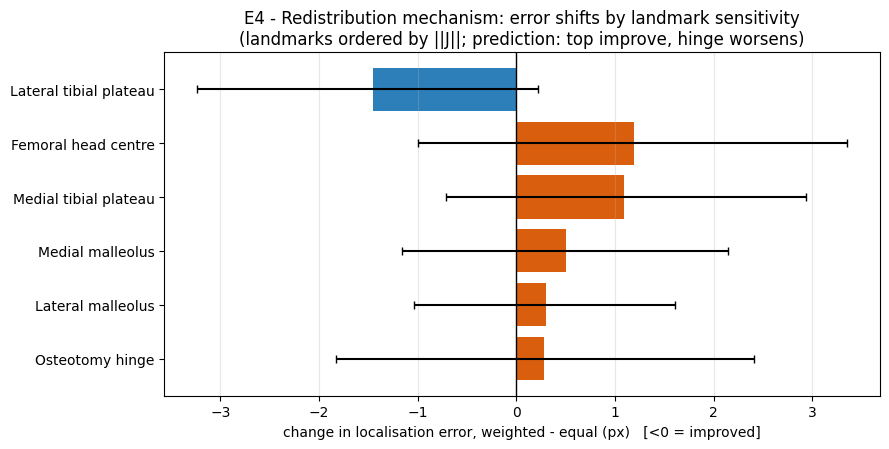

In [10]:
if mech is not None:
    order = list(mech.landmark)
    fig, ax = plt.subplots(figsize=(9, 4.6))
    y = np.arange(len(order))
    colors = ["#2c7fb8" if d < 0 else "#d95f0e" for d in mech.delta_err_px]
    ax.barh(y, mech.delta_err_px, color=colors,
            xerr=[mech.delta_err_px - mech.ci_lo, mech.ci_hi - mech.delta_err_px],
            capsize=3)
    ax.axvline(0, color="k", lw=1)
    ax.set_yticks(y); ax.set_yticklabels([LANDMARK_LABELS[k] for k in order])
    ax.invert_yaxis()
    ax.set_xlabel("change in localisation error, weighted - equal (px)   [<0 = improved]")
    ax.set_title("E4 - Redistribution mechanism: error shifts by landmark sensitivity\n"
                 "(landmarks ordered by ||J||; prediction: top improve, hinge worsens)")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout(); fig.savefig(OUT_DIR / "E4_fig1_mechanism.png", dpi=200); plt.show()

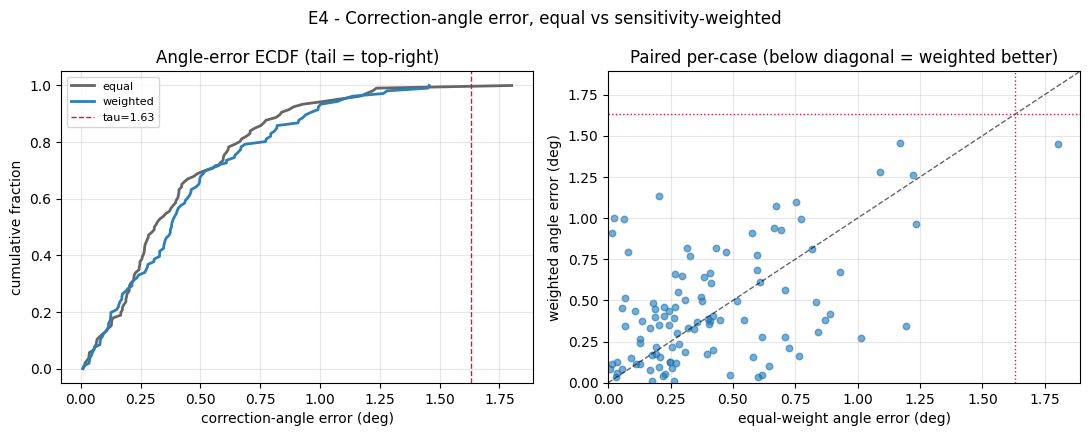

In [11]:
if {"equal", "weighted"} <= set(df.arm.unique()):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
    for arm, c in [("equal", "#666"), ("weighted", "#2c7fb8")]:
        x = df[df.arm == arm].angle_err.values
        x = np.sort(x[np.isfinite(x)])                     # drop degenerate for the ECDF
        a1.plot(x, np.linspace(0, 1, len(x)), label=arm, color=c, lw=2)
    a1.axvline(TOLERANCE_DEG, color="crimson", ls="--", lw=1, label=f"tau={TOLERANCE_DEG}")
    a1.set_xlabel("correction-angle error (deg)"); a1.set_ylabel("cumulative fraction")
    a1.set_title("Angle-error ECDF (tail = top-right)"); a1.legend(fontsize=8); a1.grid(alpha=0.3)

    e = df[df.arm == "equal"].set_index(["case_id", "side"])
    w = df[df.arm == "weighted"].set_index(["case_id", "side"])
    common = e.index.intersection(w.index)
    a2.scatter(e.loc[common, "angle_err"], w.loc[common, "angle_err"], s=22, alpha=0.6)
    lim = float(max(e.angle_err.max(), w.angle_err.max())) * 1.05
    a2.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.6)
    a2.axhline(TOLERANCE_DEG, color="crimson", ls=":", lw=1)
    a2.axvline(TOLERANCE_DEG, color="crimson", ls=":", lw=1)
    a2.set_xlabel("equal-weight angle error (deg)"); a2.set_ylabel("weighted angle error (deg)")
    a2.set_title("Paired per-case (below diagonal = weighted better)")
    a2.set_xlim(0, lim); a2.set_ylim(0, lim); a2.grid(alpha=0.3)
    fig.suptitle("E4 - Correction-angle error, equal vs sensitivity-weighted")
    fig.tight_layout(); fig.savefig(OUT_DIR / "E4_fig2_angle.png", dpi=200); plt.show()

## 10 · Export

In [12]:
manifest = {
    "experiment": "Paper A / E4 - sensitivity-weighted loss",
    "dev_mode": DEV_MODE, "arms": ARMS, "n_splits": N_SPLITS, "epochs": EPOCHS,
    "weight_mode": WEIGHT_MODE, "weight_power": WEIGHT_POWER,
    "use_measurement": USE_MEASUREMENT, "measurement_lambda": MEASUREMENT_LAMBDA,
    "seed": SEED, "tolerance_deg": TOLERANCE_DEG,
    "n_hemispheres_per_arm": {a: int((df.arm == a).sum()) for a in df.arm.unique()},
    "matched_mre": {a: float(df[df.arm == a].mre.mean()) for a in df.arm.unique()},
    "angle_summary": {a: {"mean": float(df[df.arm == a].angle_err.mean()),
                          "p95": float(df[df.arm == a].angle_err.quantile(0.95)),
                          "max": float(df[df.arm == a].angle_err.max()),
                          "within_tol": float((df[df.arm == a].angle_err <= TOLERANCE_DEG).mean())}
                      for a in df.arm.unique()},
    "median_J_norm": {k: float(v) for k, v in zip(SIDE_KEYS, J_norm_median)},
}
if mech is not None:
    manifest["mechanism_corr_J_vs_delta"] = float(
        np.corrcoef(mech["||J||"], mech["delta_err_px"])[0, 1])
    manifest["mechanism_agreement"] = f"{int(mech.agrees.sum())}/{len(mech)}"
(OUT_DIR / "E4_manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"written to {OUT_DIR.resolve()}")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}")

written to /tf/notebooks/results/E4
  E4_angle_tail.csv
  E4_fig1_mechanism.png
  E4_fig2_angle.png
  E4_manifest.json
  E4_mechanism.csv
  E4_per_case.csv


## 11 · Reading the result

- **Matched MRE (§6).** If the weighted arm's MRE ≈ the equal arm's, the angle comparison is
  clean redistribution. If MRE also fell, say so — the effect is confounded with accuracy.
- **Mechanism (§7).** The pre-registered claim. Look for Δ-error < 0 on the plateau and
  femoral head, Δ > 0 on the hinge, and a negative corr(‖J‖, Δ). This is where the power is.
- **Angle tail (§8).** A descriptive read at the upper quantiles with CIs. An in-domain null
  here is an honest, pre-committed outcome — E1 already showed the mean is saturated.
- **Decode floor.** If the mechanism fires but the angle tail doesn't move, the ~9 px argmax
  quantisation is the likely cap; rerun with `USE_MEASUREMENT = True` (soft-argmax + the
  measurement term), which bypasses it.

In [13]:
bar = "=" * 72
lines = [bar, "E4 - RESULT" + ("  [DEV_MODE smoke test - not final]" if DEV_MODE else ""), bar]
for a in df.arm.unique():
    s = df[df.arm == a]
    lines.append(f"  {a:14s} MRE {s.mre.mean():5.2f} px | angle mean {s.angle_err.mean():.3f} "
                 f"p95 {s.angle_err.quantile(0.95):.3f} max {s.angle_err.max():.3f} "
                 f"| within tol {100 * (s.angle_err <= TOLERANCE_DEG).mean():.1f}%")
if mech is not None:
    lines += ["",
              f"  Mechanism: corr(||J||, delta_err) = "
              f"{np.corrcoef(mech['||J||'], mech['delta_err_px'])[0, 1]:+.3f}, "
              f"prediction agrees on {int(mech.agrees.sum())}/{len(mech)} landmarks"]
lines.append(bar)
print("\n".join(lines))

E4 - RESULT
  equal          MRE 17.52 px | angle mean 0.412 p95 1.066 max 1.801 | within tol 99.1%
  weighted       MRE 17.84 px | angle mean 0.448 p95 1.092 max 1.456 | within tol 100.0%

  Mechanism: corr(||J||, delta_err) = -0.417, prediction agrees on 4/6 landmarks
